In [12]:
!pip install -q kagglehub opencv-python-headless scikit-image

## Task 1 — Load the Image

Uses the same HAM10000 dataset as the earlier labs, downloaded directly into Colab via `kagglehub` — no `kaggle.json` file needed (you'll paste your Kaggle username + API key once when prompted). We pick **5 sample lesion images** to work with throughout this notebook (the lab's Task 5 table asks for 5 images).

In [2]:
import kagglehub, os, glob
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", path)

metadata_path = glob.glob(os.path.join(path, "**", "HAM10000_metadata.csv"), recursive=True)[0]
df = pd.read_csv(metadata_path)

image_paths = {}
for f in glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True):
    image_id = os.path.splitext(os.path.basename(f))[0]
    image_paths[image_id] = f

df["path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["path"]).reset_index(drop=True)
print("Total labeled images found:", len(df))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000
Total labeled images found: 10015


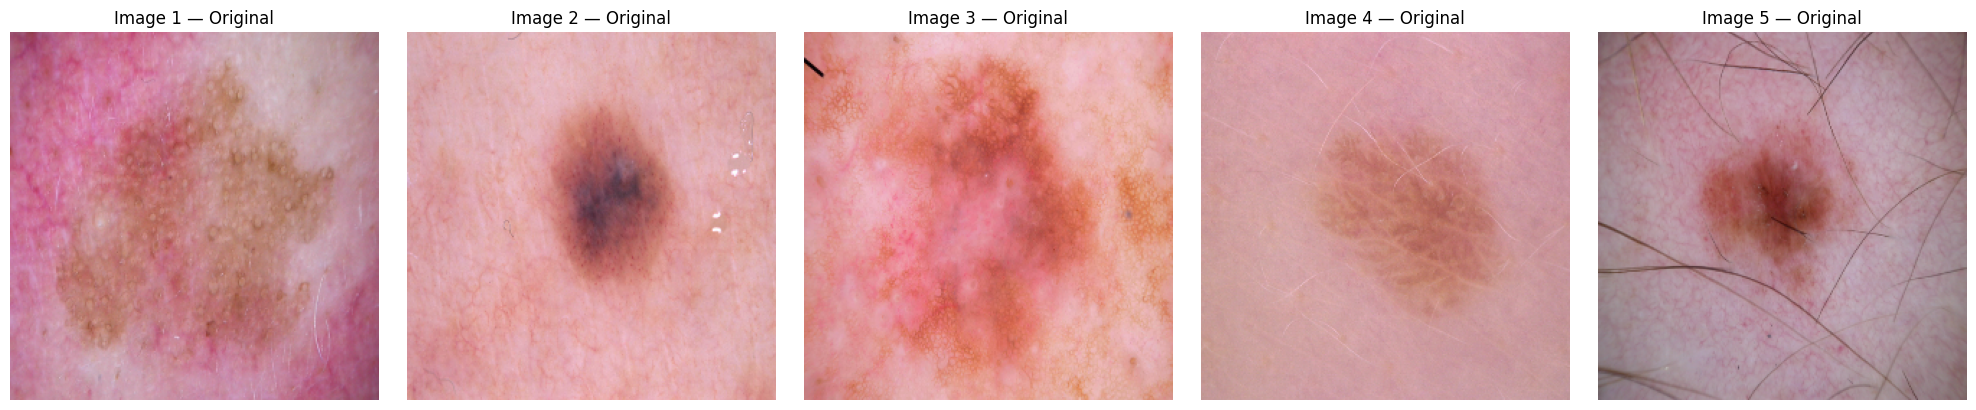

In [3]:
def load_rgb(path, size=256):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

# ---- EDIT this if you want specific images instead ----
N_IMAGES = 5
sample_df = df.sample(n=N_IMAGES, random_state=42).reset_index(drop=True)
images = {f"Image {i+1}": load_rgb(row["path"]) for i, row in sample_df.iterrows()}

fig, axes = plt.subplots(1, N_IMAGES, figsize=(4 * N_IMAGES, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(f"{name} — Original")
    ax.axis("off")
plt.tight_layout()
plt.savefig("task1_originals.png", dpi=150)
plt.show()

## Task 2 — Preprocess the Image

Convert to grayscale, then apply a Gaussian filter to reduce noise.

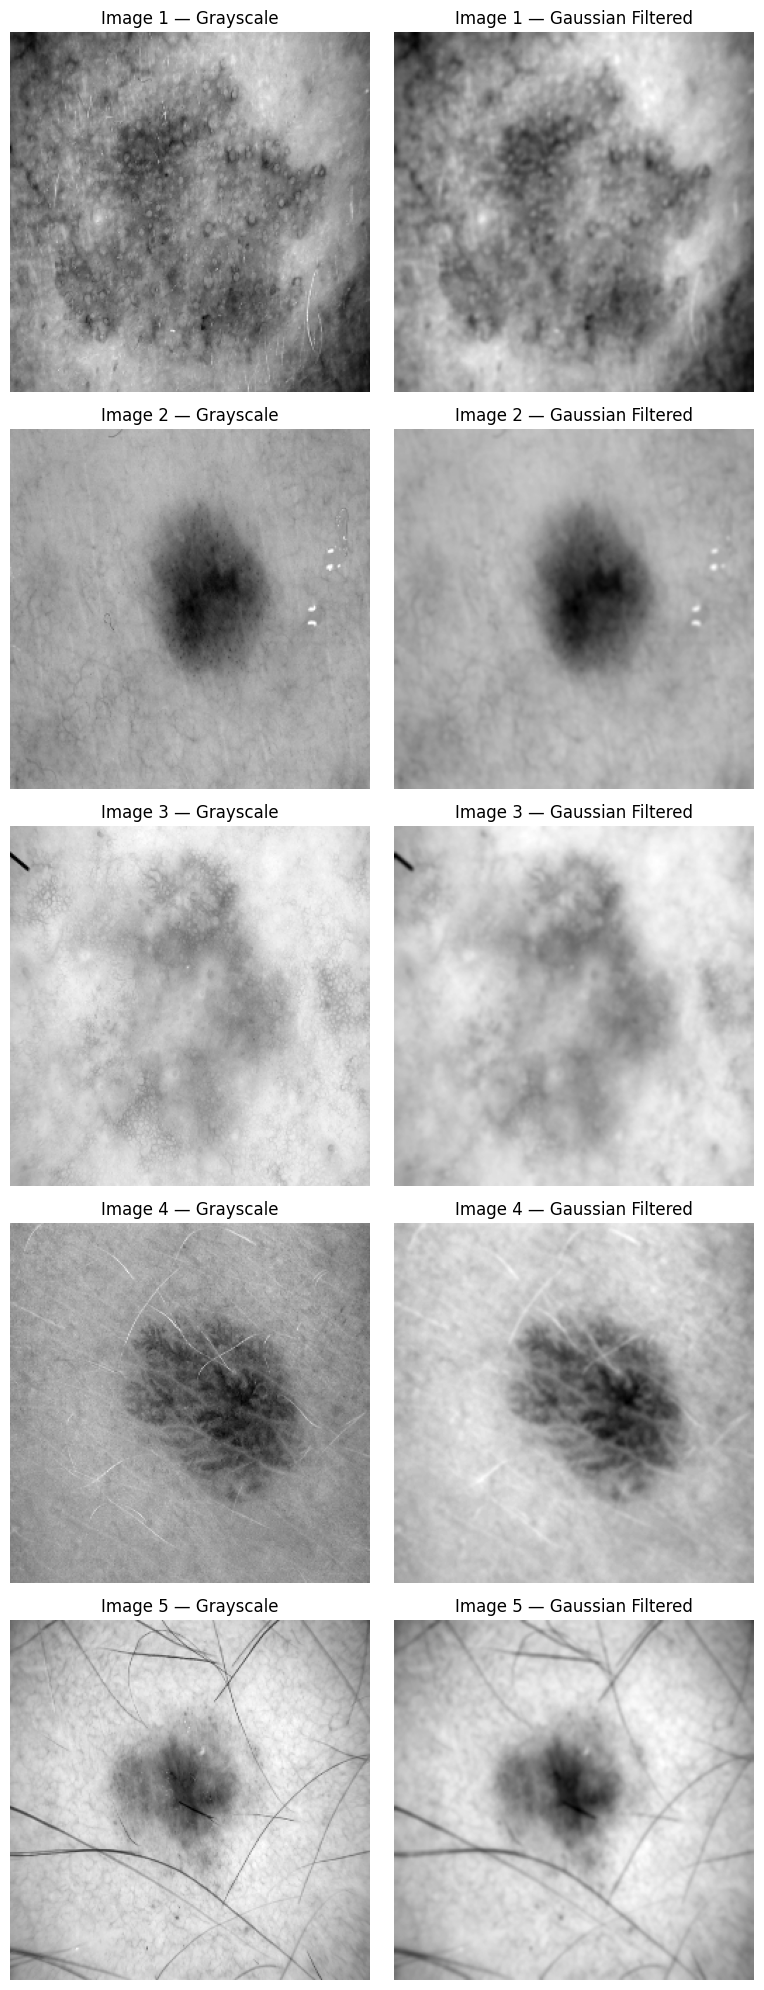

In [13]:
def to_gray(img_rgb):
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def gaussian_filter(gray, ksize=5, sigma=0):
    return cv2.GaussianBlur(gray, (ksize, ksize), sigma)

grayscale_imgs = {name: to_gray(img) for name, img in images.items()}
filtered_imgs = {name: gaussian_filter(gray) for name, gray in grayscale_imgs.items()}

fig, axes = plt.subplots(N_IMAGES, 2, figsize=(8, 4 * N_IMAGES))
for i, name in enumerate(images):
    axes[i, 0].imshow(grayscale_imgs[name], cmap="gray")
    axes[i, 0].set_title(f"{name} — Grayscale")
    axes[i, 1].imshow(filtered_imgs[name], cmap="gray")
    axes[i, 1].set_title(f"{name} — Gaussian Filtered")
    for j in range(2):
        axes[i, j].axis("off")
plt.tight_layout()
plt.savefig("task2_preprocessing.png", dpi=150)
plt.show()

## Task 3 — Apply Canny Edge Detection (3 threshold settings)

Tests **50–100, 100–200, 150–250** on every image.

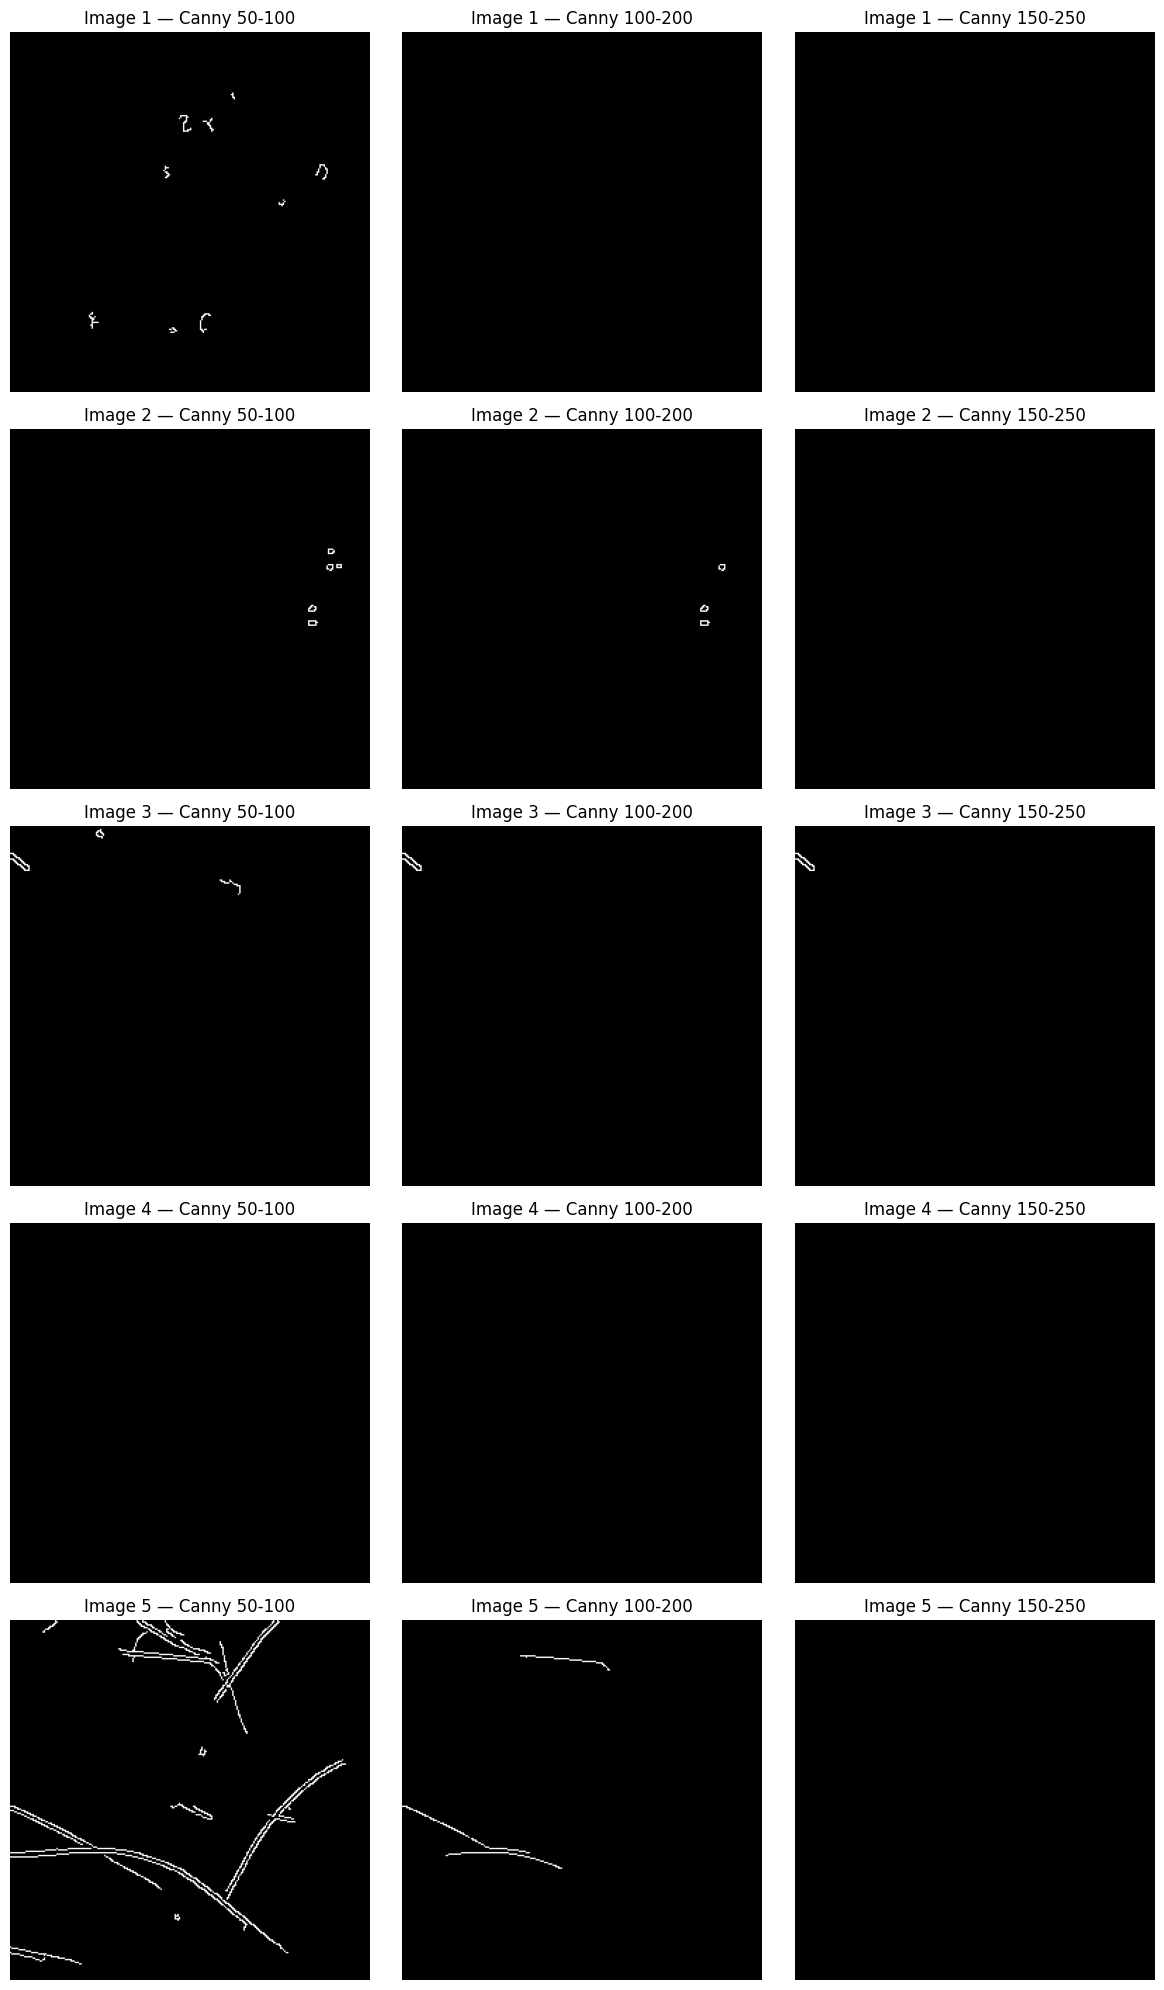

In [14]:
CANNY_SETTINGS = [
    {"name": "50-100",  "low": 50,  "high": 100},
    {"name": "100-200", "low": 100, "high": 200},
    {"name": "150-250", "low": 150, "high": 250},
]

def canny_edges(gray, low, high):
    return cv2.Canny(gray, low, high)

canny_results = {}  # (image_name, setting_name) -> edge map
for name in images:
    for cfg in CANNY_SETTINGS:
        canny_results[(name, cfg["name"])] = canny_edges(filtered_imgs[name], cfg["low"], cfg["high"])

fig, axes = plt.subplots(N_IMAGES, 3, figsize=(12, 4 * N_IMAGES))
for i, name in enumerate(images):
    for j, cfg in enumerate(CANNY_SETTINGS):
        axes[i, j].imshow(canny_results[(name, cfg["name"])], cmap="gray")
        axes[i, j].set_title(f"{name} — Canny {cfg['name']}")
        axes[i, j].axis("off")
plt.tight_layout()
plt.savefig("task3_canny_thresholds.png", dpi=150)
plt.show()

## Task 4 — Select the Best Result

We quantify "clearest lesion boundary" with two signals per threshold setting, averaged across all 5 images:
- **Edge density** (% of pixels marked as edges) — too low misses the boundary, too high is noisy
- **Largest-contour closedness** — whether the biggest connected contour found from that edge map plausibly represents one closed lesion boundary (reasonable area, not the whole image, not near-zero)

The setting whose edge density sits closest to a balanced target range, while still producing one dominant closed contour, is selected automatically below — but **look at `task3_canny_thresholds.png` yourself and confirm you agree** before writing your explanation in Task 4's answer.

In [15]:
def edge_density(edge_img):
    return 100 * np.count_nonzero(edge_img) / edge_img.size

def largest_contour_area_fraction(edge_img):
    contours, _ = cv2.findContours(edge_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    largest = max(contours, key=cv2.contourArea)
    return cv2.contourArea(largest) / edge_img.size * 100

setting_scores = []
for cfg in CANNY_SETTINGS:
    densities = [edge_density(canny_results[(name, cfg["name"])]) for name in images]
    area_fracs = [largest_contour_area_fraction(canny_results[(name, cfg["name"])]) for name in images]
    avg_density = np.mean(densities)
    avg_area_frac = np.mean(area_fracs)
    setting_scores.append({"Setting": cfg["name"], "Avg Edge Density (%)": round(avg_density, 2),
                            "Avg Largest-Contour Area (% of image)": round(avg_area_frac, 2)})

scores_df = pd.DataFrame(setting_scores)
print(scores_df)

# Pick the setting with density closest to a balanced ~6% target, among those with a nontrivial contour
target_density = 6.0
scores_df["_dist"] = (scores_df["Avg Edge Density (%)"] - target_density).abs()
best_setting_name = scores_df.loc[scores_df["_dist"].idxmin(), "Setting"]
best_cfg = next(c for c in CANNY_SETTINGS if c["name"] == best_setting_name)
print(f"\nAuto-selected best threshold: {best_setting_name} (low={best_cfg['low']}, high={best_cfg['high']})")

   Setting  Avg Edge Density (%)  Avg Largest-Contour Area (% of image)
0   50-100                  0.64                                   0.03
1  100-200                  0.11                                   0.02
2  150-250                  0.01                                   0.01

Auto-selected best threshold: 50-100 (low=50, high=100)


## Task 5 — Detect the Lesion Boundary

Uses **contour detection** on the best Canny edge map (selected above) to find the lesion boundary, then draws it on the original image.

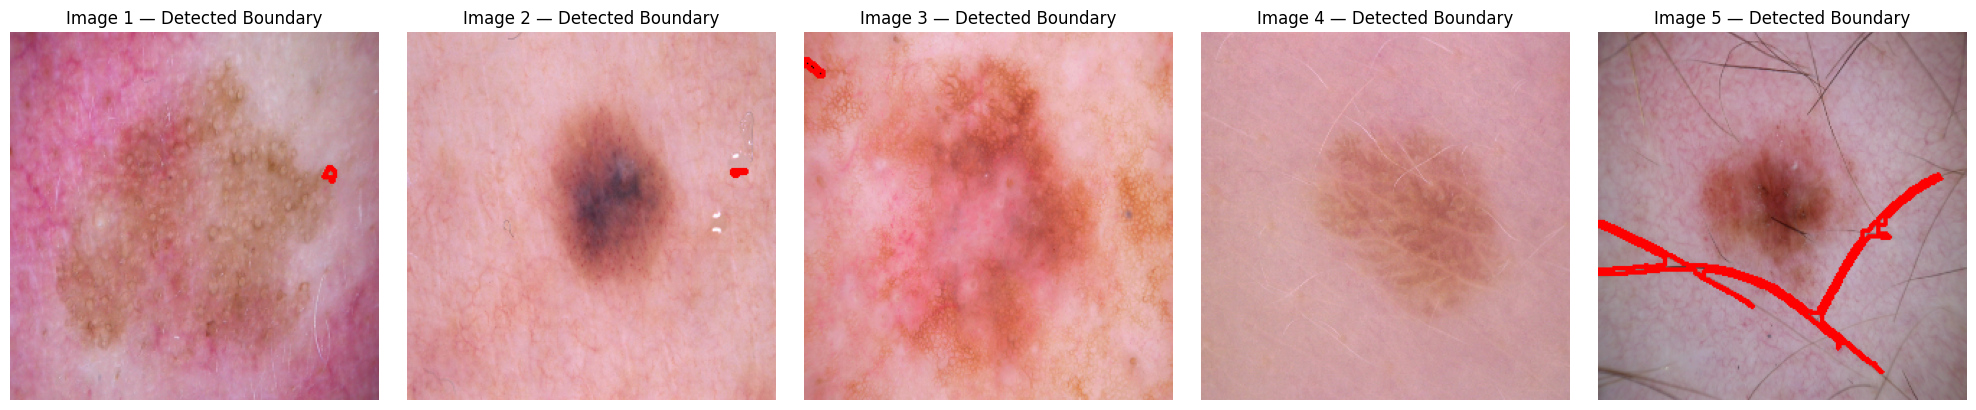

In [16]:
def detect_boundary(img_rgb, edge_map):
    # Light morphological closing helps connect small gaps in the Canny edges before contour detection
    kernel = np.ones((3, 3), np.uint8)
    closed = cv2.morphologyEx(edge_map, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_rgb.copy(), None

    largest = max(contours, key=cv2.contourArea)
    boundary_img = img_rgb.copy()
    cv2.drawContours(boundary_img, [largest], -1, (255, 0, 0), 2)
    return boundary_img, largest

boundary_imgs = {}
lesion_contours = {}
for name in images:
    best_edge_map = canny_results[(name, best_setting_name)]
    boundary_img, contour = detect_boundary(images[name], best_edge_map)
    boundary_imgs[name] = boundary_img
    lesion_contours[name] = contour

fig, axes = plt.subplots(1, N_IMAGES, figsize=(4 * N_IMAGES, 4))
for ax, name in zip(axes, images):
    ax.imshow(boundary_imgs[name])
    ax.set_title(f"{name} — Detected Boundary")
    ax.axis("off")
plt.tight_layout()
plt.savefig("task5_boundaries.png", dpi=150)
plt.show()

## Task 6 — Calculate Lesion Area & Perimeter

Area and perimeter of the detected contour, in pixels, for every image — fills the required results table.

In [17]:
results_table = []
for name in images:
    contour = lesion_contours[name]
    if contour is not None:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
    else:
        area, perimeter = 0.0, 0.0
    results_table.append({
        "Image": name, "Best Filter": "Gaussian", "Edge Method": f"Canny ({best_setting_name})",
        "Area (pixels)": round(area, 1), "Perimeter (pixels)": round(perimeter, 1),
    })

results_df = pd.DataFrame(results_table)
results_df.to_csv("task6_area_perimeter.csv", index=False)
results_df

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny (50-100),44.0,31.3
1,Image 2,Gaussian,Canny (50-100),26.0,25.7
2,Image 3,Gaussian,Canny (50-100),62.0,40.6
3,Image 4,Gaussian,Canny (50-100),0.0,0.0
4,Image 5,Gaussian,Canny (50-100),1386.0,983.7


## Required Visualization: Original → Grayscale → Gaussian → Canny → Lesion Boundary

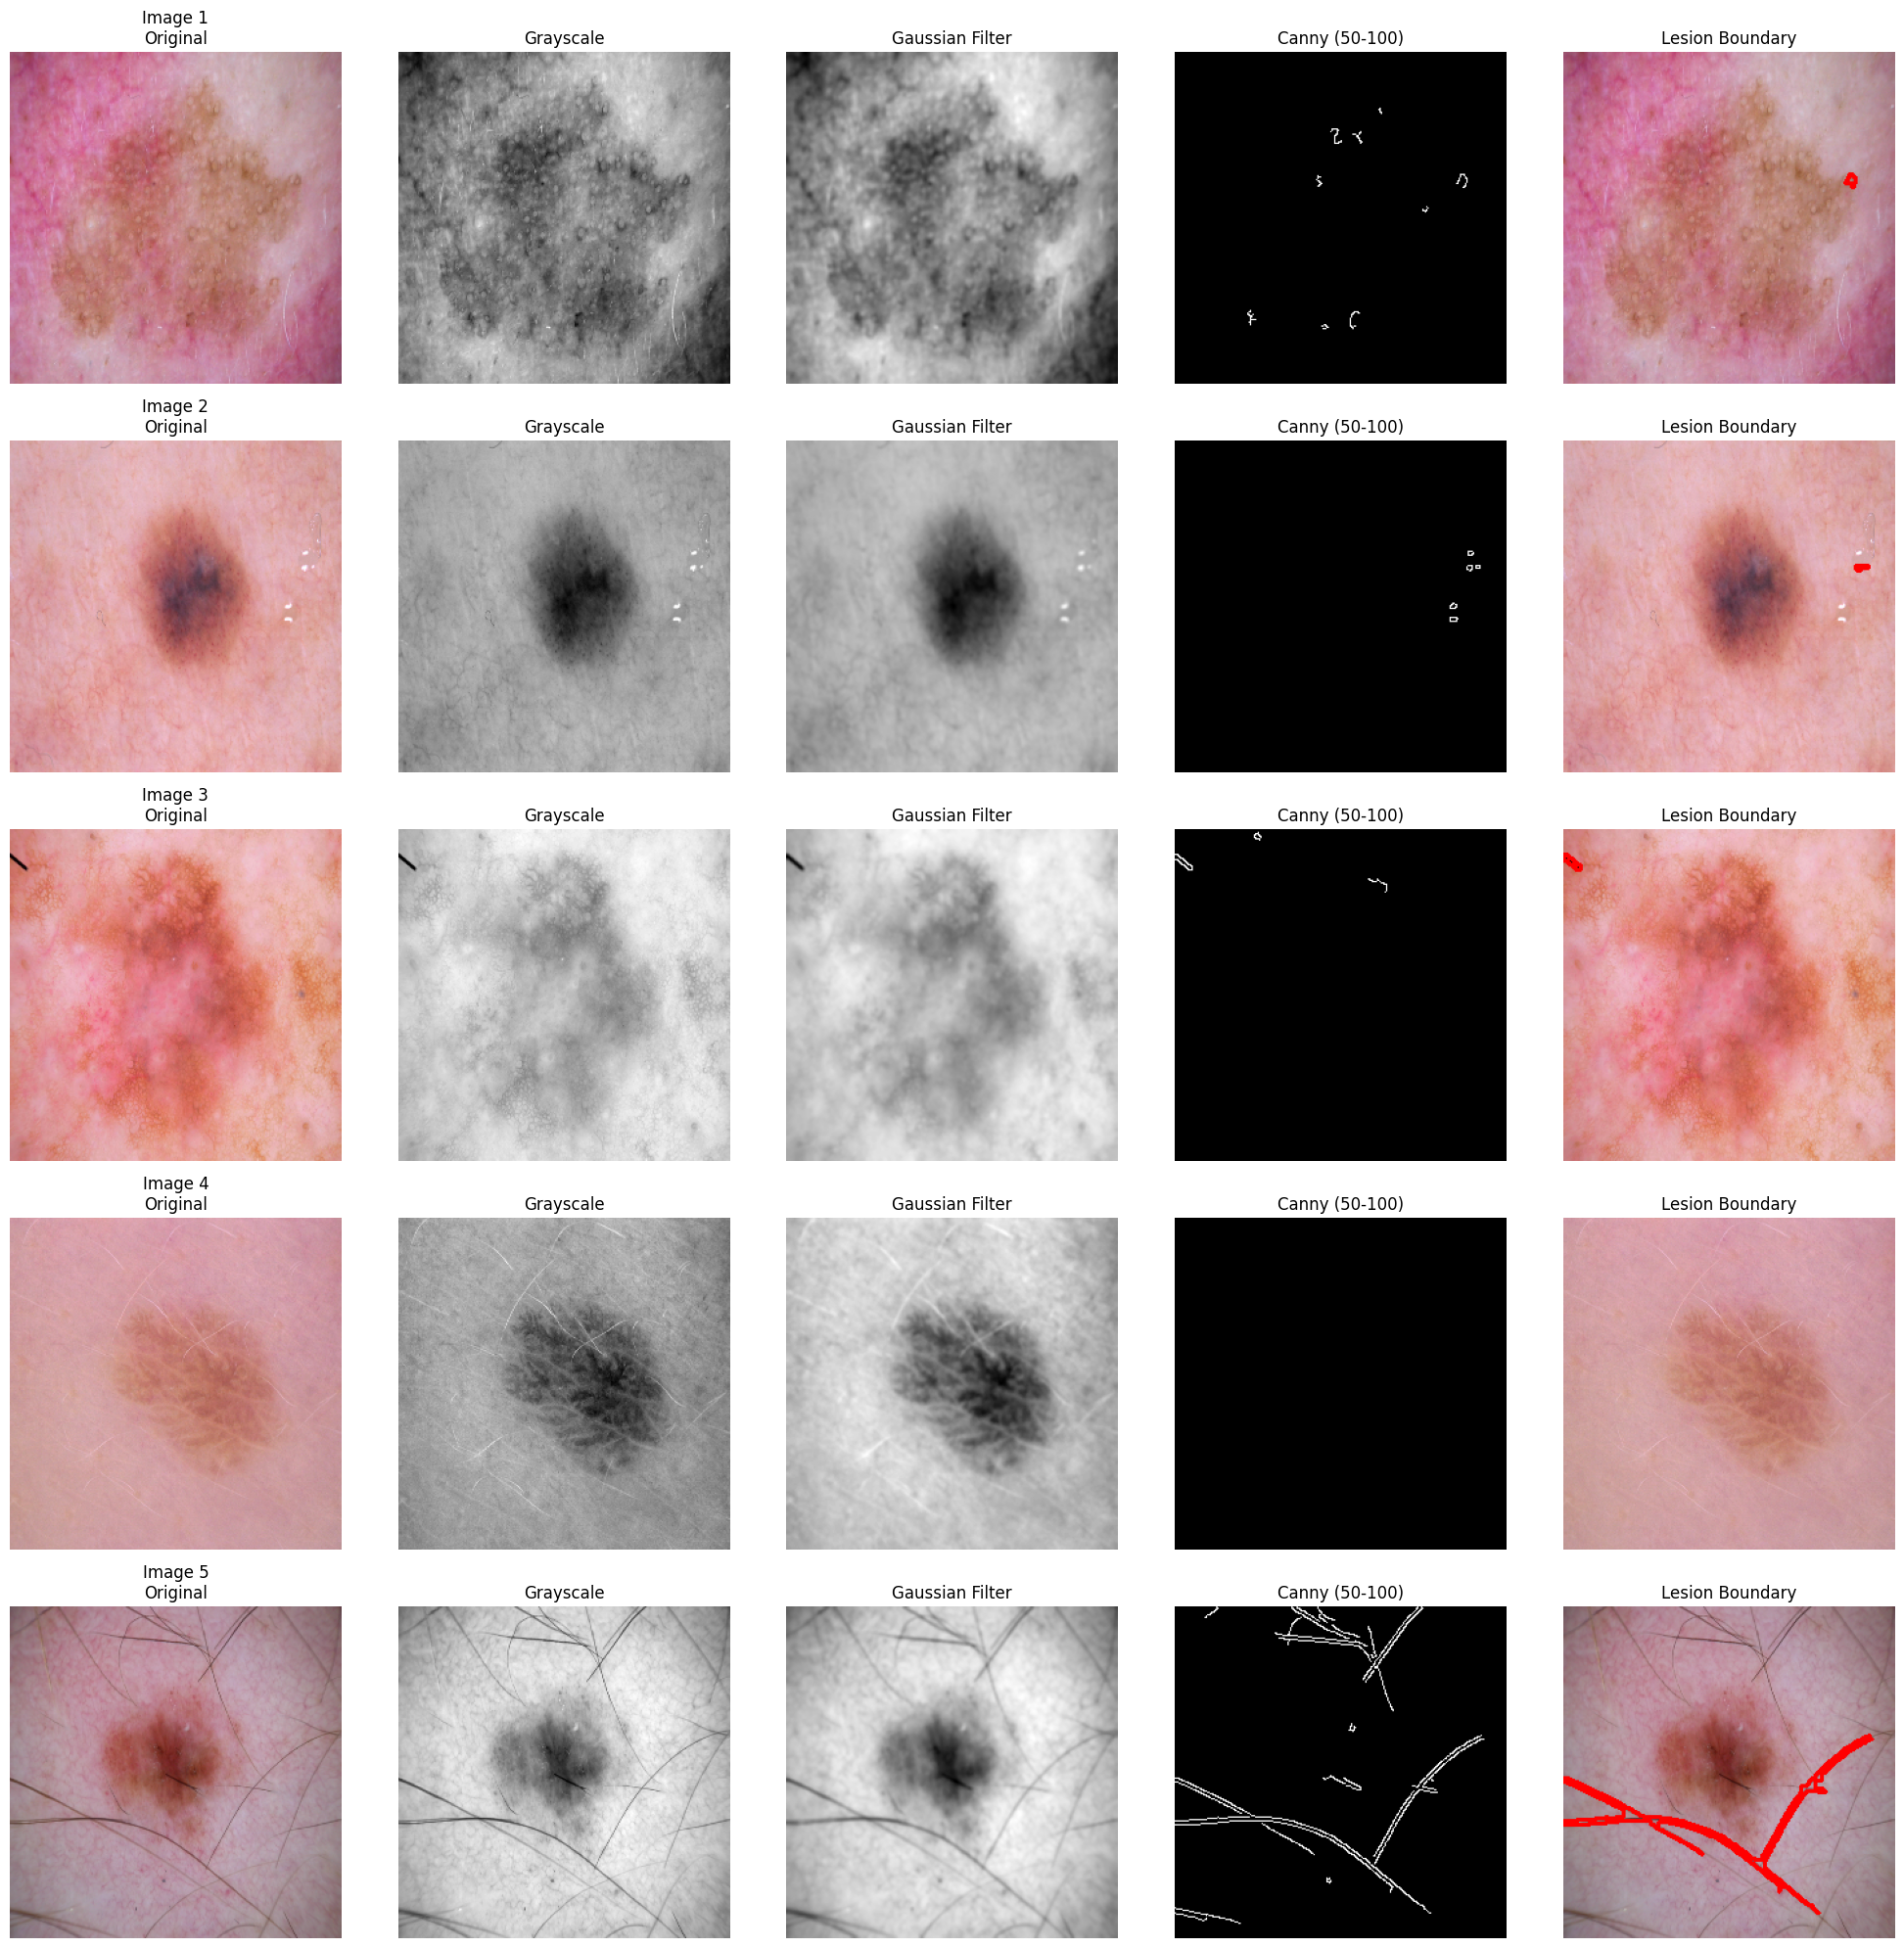

In [18]:
fig, axes = plt.subplots(N_IMAGES, 5, figsize=(20, 4 * N_IMAGES))
for i, name in enumerate(images):
    axes[i, 0].imshow(images[name]); axes[i, 0].set_title(f"{name}\nOriginal")
    axes[i, 1].imshow(grayscale_imgs[name], cmap="gray"); axes[i, 1].set_title("Grayscale")
    axes[i, 2].imshow(filtered_imgs[name], cmap="gray"); axes[i, 2].set_title("Gaussian Filter")
    axes[i, 3].imshow(canny_results[(name, best_setting_name)], cmap="gray"); axes[i, 3].set_title(f"Canny ({best_setting_name})")
    axes[i, 4].imshow(boundary_imgs[name]); axes[i, 4].set_title("Lesion Boundary")
    for j in range(5):
        axes[i, j].axis("off")
plt.tight_layout()
plt.savefig("full_pipeline_visualization.png", dpi=150)
plt.show()

## Final Comparison Table: Preprocessing × Edge Method

Tests **4 preprocessing options** (Original/no filter, Average, Gaussian, Median) crossed with **2 edge methods** (Sobel, Canny) = 8 combinations.

To make "Noise Handling" a meaningful column, each combination is tested on a version of the image with added Gaussian noise, and compared (via SSIM) against the same method's result on the clean image — a bigger difference means worse noise handling.

In [19]:
from skimage.metrics import structural_similarity as ssim

def add_gaussian_noise(gray, sigma=20):
    noise = np.random.normal(0, sigma, gray.shape)
    noisy = gray.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def average_filter(gray, ksize=5):
    return cv2.blur(gray, (ksize, ksize))

def median_filter(gray, ksize=5):
    return cv2.medianBlur(gray, ksize)

def sobel_binary(gray, thresh=50):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    mag = (255 * mag / (mag.max() + 1e-8)).astype(np.uint8)
    _, binary = cv2.threshold(mag, thresh, 255, cv2.THRESH_BINARY)
    return binary

PREPROCESS = {
    "Original": lambda g: g,
    "Average": average_filter,
    "Gaussian": gaussian_filter,
    "Median": median_filter,
}
EDGE_METHODS_FINAL = {
    "Sobel": sobel_binary,
    "Canny": lambda g: canny_edges(g, best_cfg["low"], best_cfg["high"]),
}

ref_name = list(images.keys())[0]
ref_gray = grayscale_imgs[ref_name]
ref_noisy = add_gaussian_noise(ref_gray)

final_rows = []
for pre_name, pre_fn in PREPROCESS.items():
    for edge_name, edge_fn in EDGE_METHODS_FINAL.items():
        clean_processed = pre_fn(ref_gray)
        noisy_processed = pre_fn(ref_noisy)
        clean_edges_map = edge_fn(clean_processed)
        noisy_edges_map = edge_fn(noisy_processed)

        score, _ = ssim(clean_edges_map, noisy_edges_map, full=True)
        noise_sensitivity = (1 - score) * 100
        if noise_sensitivity < 15:
            noise_handling = "Good"
        elif noise_sensitivity < 35:
            noise_handling = "Moderate"
        else:
            noise_handling = "Poor"

        density = edge_density(clean_edges_map)
        if density < 2:
            edge_quality = "Sparse"
        elif density > 15:
            edge_quality = "Noisy/Dense"
        else:
            edge_quality = "Balanced"

        contours, _ = cv2.findContours(clean_edges_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_frac = cv2.contourArea(max(contours, key=cv2.contourArea)) / clean_edges_map.size * 100
        else:
            largest_frac = 0
        if largest_frac > 1:
            boundary_detection = "Closed contour found"
        elif largest_frac > 0:
            boundary_detection = "Partial/fragmented"
        else:
            boundary_detection = "No usable contour"

        # simple composite score for "Overall Performance"
        good_count = sum([noise_handling == "Good", edge_quality == "Balanced", boundary_detection == "Closed contour found"])
        overall = ["Poor", "Fair", "Good", "Best"][good_count]

        final_rows.append({
            "Method": f"{pre_name} + {edge_name}", "Noise Handling": noise_handling,
            "Edge Quality": edge_quality, "Boundary Detection": boundary_detection,
            "Overall Performance": overall,
        })

final_comparison_df = pd.DataFrame(final_rows)
final_comparison_df.to_csv("final_comparison_table.csv", index=False)
final_comparison_df

,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Poor,Noisy/Dense,Partial/fragmented,Poor
1,Original + Canny,Poor,Balanced,Partial/fragmented,Fair
2,Average + Sobel,Poor,Noisy/Dense,Closed contour found,Fair
3,Average + Canny,Good,Sparse,No usable contour,Fair
4,Gaussian + Sobel,Poor,Noisy/Dense,Closed contour found,Fair
5,Gaussian + Canny,Poor,Sparse,Partial/fragmented,Poor
6,Median + Sobel,Poor,Noisy/Dense,Closed contour found,Fair
7,Median + Canny,Moderate,Sparse,Partial/fragmented,Poor


## Questions to Answer

Questions 2 and 3 are auto-answered below using your actual threshold scores from Task 4. Questions 1, 4, 5, 6 are answered as text — read them, then adjust based on what you actually see in your own figures before submitting.

In [21]:
# Q2 & Q3: effect of the 3 threshold settings, and which was best
print("Q2/Q3 — Canny threshold comparison (averaged across all 5 images):")
print(scores_df.drop(columns=["_dist"]))
print(f"\nSelected best setting: {best_setting_name}")

Q2/Q3 — Canny threshold comparison (averaged across all 5 images):
   Setting  Avg Edge Density (%)  Avg Largest-Contour Area (% of image)
0   50-100                  0.64                                   0.03
1  100-200                  0.11                                   0.02
2  150-250                  0.01                                   0.01

Selected best setting: 50-100


**Q1. Why is Gaussian filtering applied before Canny detection?**

Canny edge detection works by computing intensity gradients, and gradients are very sensitive to noise — a single noisy pixel can create a large, spurious gradient that gets mistaken for a real edge. Applying a Gaussian filter first smooths out that noise while preserving the overall intensity transitions at true object boundaries, so the gradient computation that follows responds to genuine lesion-boundary transitions rather than pixel-level noise. (This is also why Canny's internal algorithm includes its own Gaussian smoothing step as stage one, even before you add an external filter.)

**Q4. Why are edges useful for detecting skin lesions?**

A skin lesion is typically visually distinguished from surrounding healthy skin by a relatively sharp transition in color/intensity at its border — the lesion is darker/differently pigmented than the skin around it. Edge detection is specifically designed to find exactly these kinds of sharp local intensity transitions, which makes it a natural tool for locating where the lesion's boundary is, independent of the lesion's internal color or texture pattern.

**Q5. What problems did you observe in detecting the lesion boundary?**

Common problems with this approach (check your own `task3_canny_thresholds.png` and `task5_boundaries.png` to confirm which applied to your images): (1) **broken/incomplete edges** — if the lesion's border has low contrast in some places, Canny may miss sections of the boundary, leaving gaps that `cv2.findContours` can't treat as one closed shape (this is why a morphological closing step was added before contour detection in Task 5); (2) **false edges from hair, skin texture, or lighting variation** — these can create extra contours that compete with the real lesion boundary, especially at lower thresholds; (3) **threshold sensitivity** — too low a threshold picks up noise as "edges," too high a threshold misses faint but real boundary sections, and the right balance can vary from image to image, so one fixed threshold setting won't be ideal for every image in a dataset.

**Q6. How could your method be improved?**

A few directions: (a) use an **adaptive/per-image threshold** (e.g. Otsu's method to pick Canny's thresholds automatically from each image's own intensity histogram) instead of one fixed setting for every image; (b) apply **color-based segmentation** (e.g. in HSV or LAB color space) alongside or instead of pure edge-based detection, since lesion boundaries are often more reliably separated by color difference than by a pure intensity gradient; (c) use a **learned segmentation model** (e.g. a U-Net trained specifically for lesion segmentation) which can learn to ignore hair/noise artifacts and generalize much better than a fixed classical pipeline; (d) add a **hair-removal preprocessing step** (a common dermoscopy preprocessing technique) before edge detection, since body hair is a frequent source of false edges in this kind of image.